## Notebook donde se reflejarán los resultados finales del proyecto

 ### correlaciones y scatter-plots de {LSM_NLTK, LSM_Spacy} x {CGC, SCOTUS, SWBD} vs. LIWC

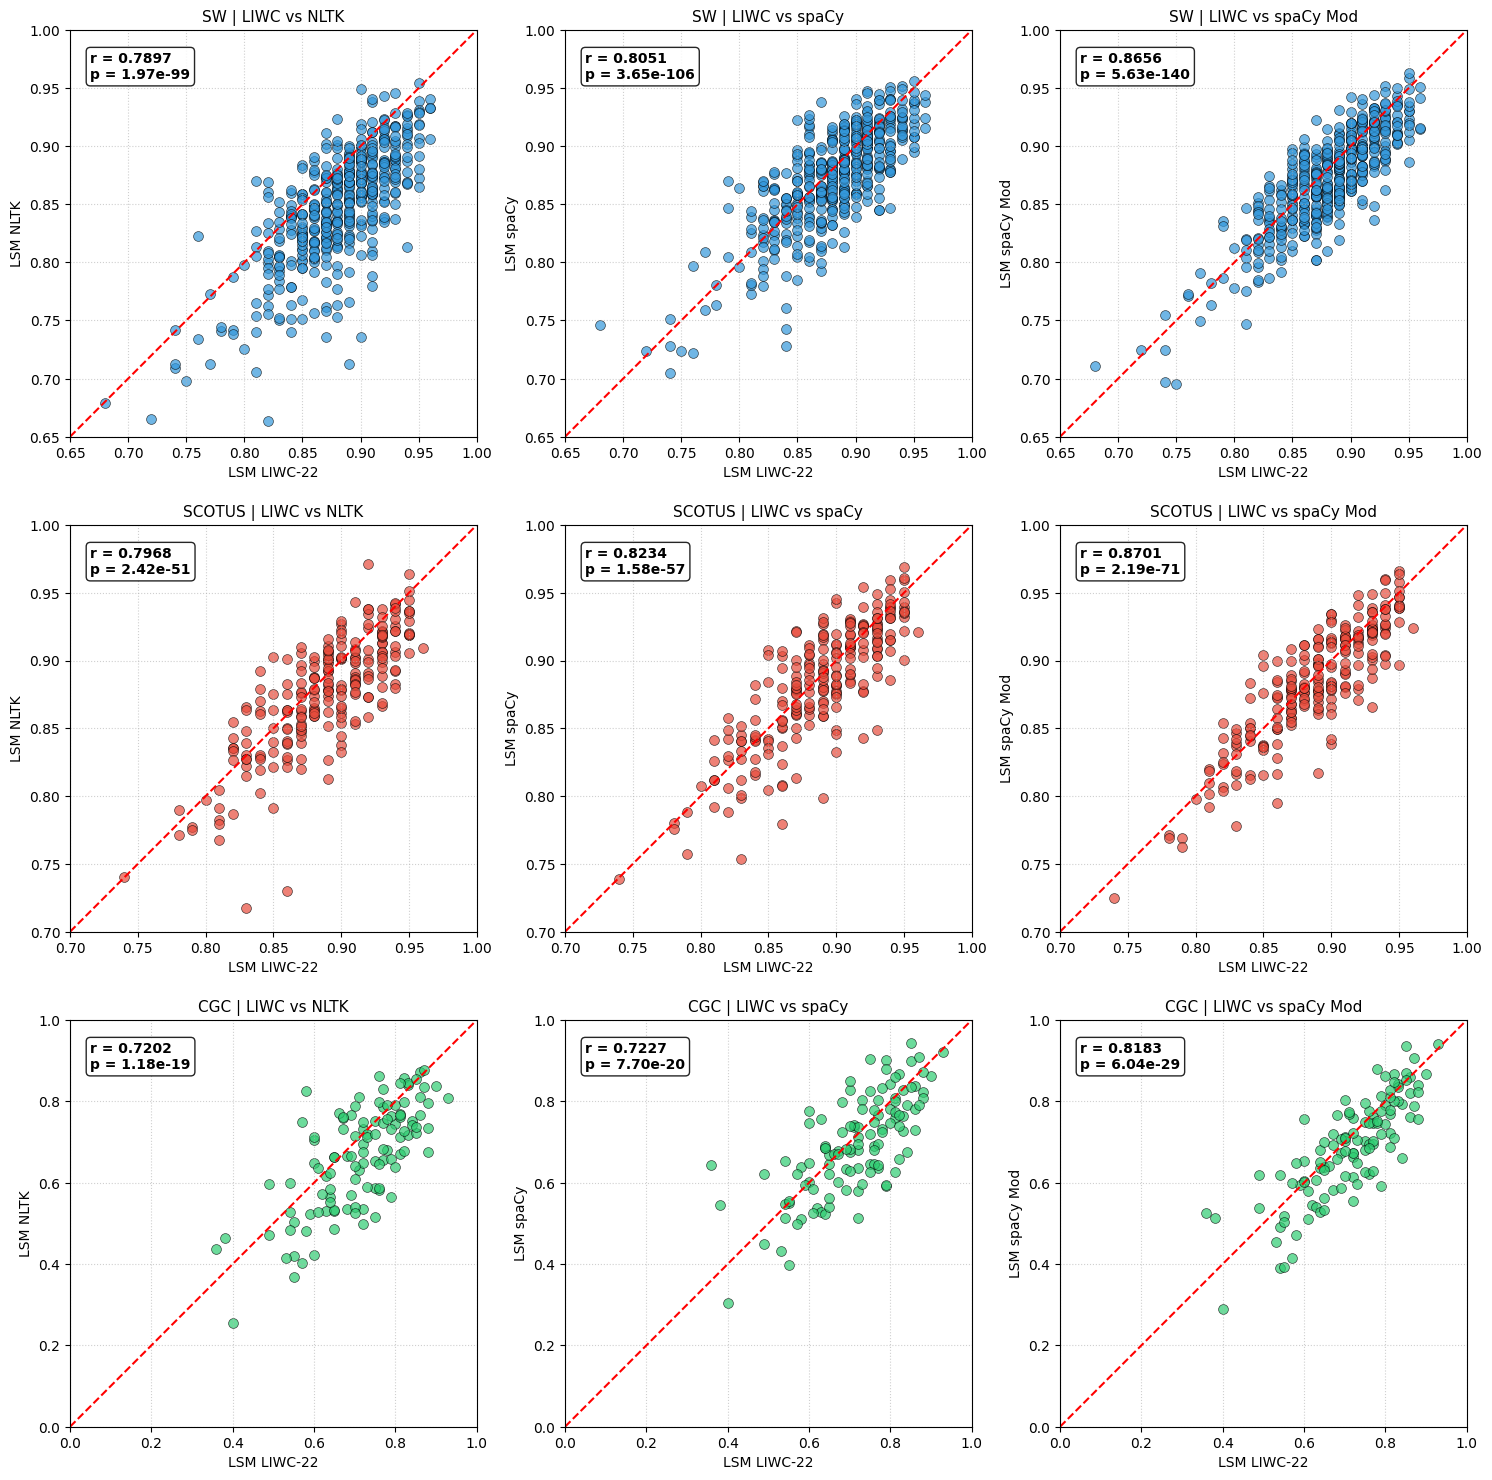

In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr

# Base path
BASE_PATH = "/home/tgallo/Documents/Proyecto_modular"

# Configuración de corpora y sus rangos
CONFIG_CORPORA = {
    "SW": {
        "grupo": "SW_PROCESSED",
        "color": "#3498db",
        "rango_min": 0.65,
        "files": {
            "NLTK": f"{BASE_PATH}/LSM_NLTK_SW.csv",
            "spaCy": f"{BASE_PATH}/LSM_SPACY_SW.csv",
            "spaCy Mod": f"{BASE_PATH}/LSM_SPACY_MOD_SW.csv",
        },
    },
    "SCOTUS": {
        "grupo": "SCOTUS",
        "color": "#e74c3c",
        "rango_min": 0.70,
        "files": {
            "NLTK": f"{BASE_PATH}/LSM_NLTK_SCOTUS.csv",
            "spaCy": f"{BASE_PATH}/LSM_SPACY_SCOTUS.csv",
            "spaCy Mod": f"{BASE_PATH}/LSM_SPACY_MOD_SCOTUS.csv",
        },
    },
    "CGC": {
        "grupo": "muestra_cgc",
        "color": "#2ecc71",
        "rango_min": 0.0,
        "files": {
            "NLTK": f"{BASE_PATH}/LSM_NLTK_CGC.csv",
            "spaCy": f"{BASE_PATH}/LSM_SPACY_CGC.csv",
            "spaCy Mod": f"{BASE_PATH}/LSM_SPACY_MOD_CGC.csv",
        },
    },
}


def plot_matriz_modelos_vs_liwc():
    modelos = ["NLTK", "spaCy", "spaCy Mod"]
    corpora = list(CONFIG_CORPORA.keys())

    fig, axes = plt.subplots(
        len(corpora), len(modelos), figsize=(15, 15), sharex=False, sharey=False
    )

    for i, corp_key in enumerate(corpora):
        cfg = CONFIG_CORPORA[corp_key]
        grupo_nombre = cfg["grupo"]
        color = cfg["color"]
        rango_min = cfg["rango_min"]

        for j, modelo in enumerate(modelos):
            ax = axes[i, j]
            csv_path = cfg["files"].get(modelo)

            if not csv_path or not os.path.exists(csv_path):
                ax.text(
                    0.5,
                    0.5,
                    f"Archivo no encontrado:\n{os.path.basename(csv_path)}",
                    ha="center",
                    va="center",
                    fontsize=9,
                )
                ax.set_title(f"{corp_key} - {modelo}")
                continue

            df = pd.read_csv(csv_path)

            # Estandarizar nombre de columna del modelo si difiere
            col_model = (
                "lsm_model" if "lsm_model" in df.columns else "lsm_spacy"
            )

            df_filtrado = df[df["grupo"] == grupo_nombre].dropna(
                subset=["lsm_liwc", col_model]
            )

            if df_filtrado.empty:
                ax.text(
                    0.5,
                    0.5,
                    "Sin datos válidos",
                    ha="center",
                    va="center",
                )
                continue

            # Cálculo de Pearson
            r_val, p_val = pearsonr(
                df_filtrado["lsm_liwc"], df_filtrado[col_model]
            )

            # Scatter plot
            ax.scatter(
                df_filtrado["lsm_liwc"],
                df_filtrado[col_model],
                color=color,
                s=50,
                alpha=0.7,
                edgecolors="black",
                linewidths=0.5,
            )

            # Línea de identidad y = x
            identidad = np.linspace(rango_min, 1, 100)
            ax.plot(
                identidad,
                identidad,
                color="red",
                linestyle="--",
                linewidth=1.5,
                label="y = x",
            )

            # Anotación de Correlación
            ax.text(
                0.05,
                0.88,
                f"r = {r_val:.4f}\np = {p_val:.2e}",
                transform=ax.transAxes,
                fontsize=10,
                fontweight="bold",
                bbox=dict(
                    boxstyle="round,pad=0.3", facecolor="white", alpha=0.85
                ),
            )

            # Formato de ejes
            ax.set_xlim(rango_min, 1.0)
            ax.set_ylim(rango_min, 1.0)
            ax.set_title(f"{corp_key} | LIWC vs {modelo}", fontsize=11)
            ax.set_xlabel("LSM LIWC-22")
            ax.set_ylabel(f"LSM {modelo}")
            ax.set_aspect("equal")
            ax.grid(True, linestyle=":", alpha=0.6)

    plt.tight_layout()
    plt.savefig("matriz_validacion_liwc_vs_modelos.png", dpi=300)
    plt.show()


if __name__ == "__main__":
    plot_matriz_modelos_vs_liwc()

### UBA VS CGC VS PENTO

--- Estadísticas Comparativas LSM ---
                count      mean       std       min       25%       50%  \
grupo                                                                     
CGC (en)        115.0  0.695259  0.122086  0.303672  0.622036  0.689510   
PENTO (de)        8.0  0.796439  0.094257  0.610999  0.781603  0.832033   
UBA Games (es)  201.0  0.717067  0.134227  0.290139  0.628950  0.753649   

                     75%       max  
grupo                               
CGC (en)        0.781628  0.943315  
PENTO (de)      0.839872  0.902448  
UBA Games (es)  0.812326  0.915552  


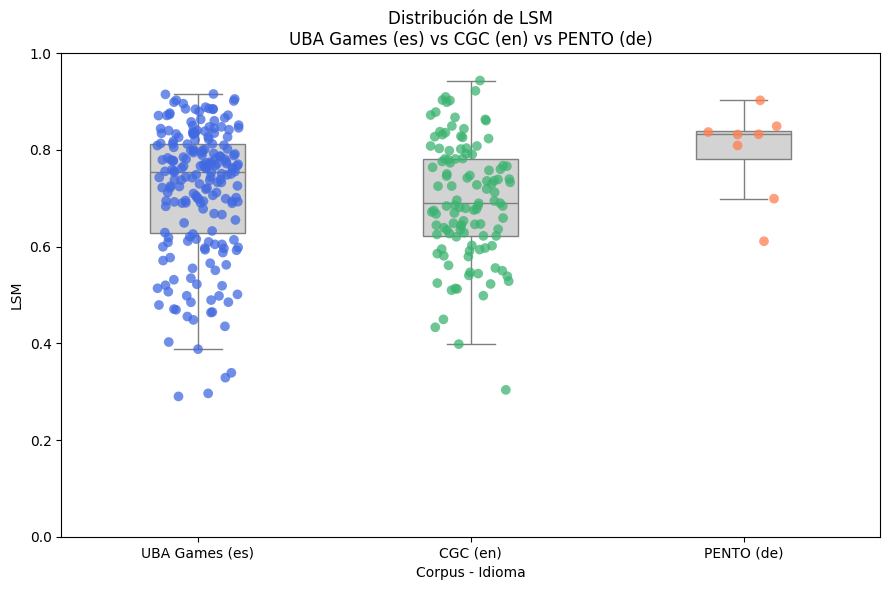

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Rutas de los CSVs
UBA_CSV = "/home/tgallo/Documents/Proyecto_modular/LSM_SPACY_UBA.csv"
CGC_CSV = "/home/tgallo/Documents/Proyecto_modular/LSM_SPACY_CGC.csv"
PENTO_CSV = "/home/tgallo/Documents/Proyecto_modular/LSM_RONDAS_AGREGADAS_R1_R8.csv"
# 1. Cargar datos
df_uba = pd.read_csv(UBA_CSV)
df_cgc = pd.read_csv(CGC_CSV)
df_pento = pd.read_csv(PENTO_CSV)

# 2. Estandarización de UBA Games (Español)
col_uba = "lsm_model" if "lsm_model" in df_uba.columns else "lsm_spacy"
df_uba = df_uba.rename(columns={col_uba: "lsm"})
df_uba["corpus"] = "UBA Games"
df_uba["idioma"] = "es"
df_uba["grupo"] = df_uba["corpus"] + " (" + df_uba["idioma"] + ")"
df_uba = df_uba[["archivo", "corpus", "idioma", "lsm", "grupo"]]

# 3. Estandarización de CGC (Inglés)
col_cgc = "lsm_model" if "lsm_model" in df_cgc.columns else "lsm_spacy"
df_cgc = df_cgc.rename(columns={col_cgc: "lsm"})
df_cgc["corpus"] = "CGC"
df_cgc["idioma"] = "en"
df_cgc["grupo"] = df_cgc["corpus"] + " (" + df_cgc["idioma"] + ")"
df_cgc = df_cgc[["archivo", "corpus", "idioma", "lsm", "grupo"]]

# 4. Estandarización de PENTO (Alemán - lsm_global y ronda)
df_pento = df_pento.rename(columns={"lsm_global": "lsm", "ronda": "archivo"})
df_pento["corpus"] = "PENTO"
df_pento["idioma"] = "de"
df_pento["grupo"] = df_pento["corpus"] + " (" + df_pento["idioma"] + ")"
df_pento = df_pento[["archivo", "corpus", "idioma", "lsm", "grupo"]]

# 5. Concatenar los tres DataFrames
df = pd.concat([df_uba, df_cgc, df_pento], ignore_index=True)

# Limpieza de valores nulos o no válidos
df = df.dropna(subset=["lsm"])
df = df[df["lsm"] > 0]

# Imprimir estadísticas descriptivas comparativas
print("--- Estadísticas Comparativas LSM ---")
print(df.groupby("grupo")["lsm"].describe())

# 6. Gráfico
plt.figure(figsize=(9, 6))

colores = {
    "UBA Games (es)": "royalblue",
    "CGC (en)": "mediumseagreen",
    "PENTO (de)": "coral",
}

# Boxplot neutro de fondo
sns.boxplot(
    data=df,
    x="grupo",
    y="lsm",
    width=0.35,
    color="lightgray",
    fliersize=0,
)

# Puntos individuales por grupo
sns.stripplot(
    data=df,
    x="grupo",
    y="lsm",
    hue="grupo",
    palette=colores,
    jitter=0.15,
    size=7,
    alpha=0.75,
    legend=False,
)

# Ajustes visuales
plt.ylabel("LSM")
plt.xlabel("Corpus - Idioma")
plt.title("Distribución de LSM\nUBA Games (es) vs CGC (en) vs PENTO (de)")

# Fijar límite Y de 0 a 1
plt.ylim(0, 1)

plt.tight_layout()

# Guardar figura
plt.savefig("boxplot_LSM_UBA_CGC_PENTO.png", dpi=300)
plt.show()

### PORTUGUES VS SW

--- Estadísticas Comparativas LSM (Portugués vs Muestra SW) ---
                       count      mean       std      min       25%       50%  \
grupo                                                                           
C-ORAL (pt)             52.0  0.764727  0.141894  0.26535  0.696610  0.818015   
SW (Muestra 100) (en)  100.0  0.879522  0.043965  0.72378  0.854206  0.884088   

                            75%       max  
grupo                                      
C-ORAL (pt)            0.869974  0.932915  
SW (Muestra 100) (en)  0.916280  0.951286  


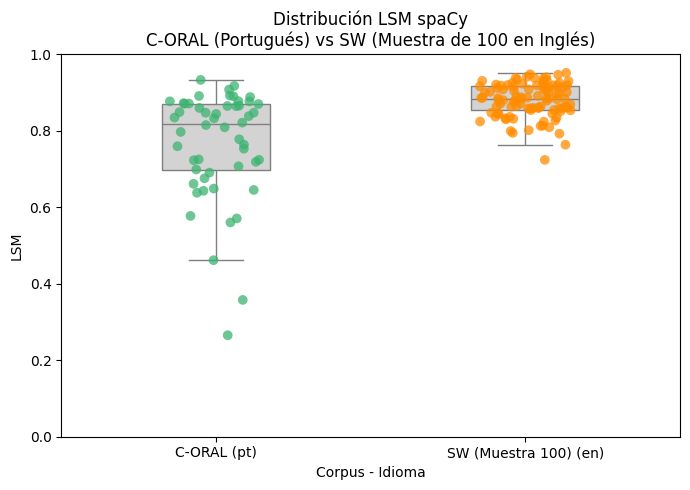

In [4]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Archivos de entrada
PT_CSV = "/home/tgallo/Documents/Proyecto_modular/LSM_SPACY_PORTUGUES.csv"
SW_CSV = "/home/tgallo/Documents/Proyecto_modular/LSM_SPACY_SW.csv"

# 1. Cargar datos
df_pt = pd.read_csv(PT_CSV)
df_sw = pd.read_csv(SW_CSV)

# 2. Estandarización Portugués (C-ORAL)
col_pt = "lsm_spacy_pt" if "lsm_spacy_pt" in df_pt.columns else "lsm"
df_pt = df_pt.rename(columns={col_pt: "lsm"})
df_pt["corpus"] = "C-ORAL"
df_pt["idioma"] = "pt"
df_pt["grupo"] = df_pt["corpus"] + " (" + df_pt["idioma"] + ")"
df_pt = df_pt[["archivo", "corpus", "idioma", "lsm", "grupo"]]

# 3. Estandarización y muestreo aleatorio (n=100) de Switchboard (SW)
if "lsm_model" in df_sw.columns:
    df_sw = df_sw.rename(columns={"lsm_model": "lsm"})
elif "lsm_spacy" in df_sw.columns:
    df_sw = df_sw.rename(columns={"lsm_spacy": "lsm"})

# Muestreo aleatorio de 100 casos
if len(df_sw) > 100:
    df_sw = df_sw.sample(n=100, random_state=42).reset_index(drop=True)

df_sw["corpus"] = "SW (Muestra 100)"
df_sw["idioma"] = "en"
df_sw["grupo"] = df_sw["corpus"] + " (" + df_sw["idioma"] + ")"
df_sw = df_sw[["archivo", "corpus", "idioma", "lsm", "grupo"]]

# 4. Concatenar DataFrames
df = pd.concat([df_pt, df_sw], ignore_index=True)

# Limpieza de nulos / valores fuera de rango
df = df.dropna(subset=["lsm"])
df = df[df["lsm"] > 0]

# Imprimir estadísticas descriptivas
print("--- Estadísticas Comparativas LSM (Portugués vs Muestra SW) ---")
print(df.groupby("grupo")["lsm"].describe())

# 5. Gráfico Boxplot
plt.figure(figsize=(7, 5))

colores = {
    "C-ORAL (pt)": "mediumseagreen",
    "SW (Muestra 100) (en)": "darkorange",
}

# Boxplot neutro
sns.boxplot(
    data=df,
    x="grupo",
    y="lsm",
    width=0.35,
    color="lightgray",
    fliersize=0,
)

# Puntos individuales
sns.stripplot(
    data=df,
    x="grupo",
    y="lsm",
    hue="grupo",
    palette=colores,
    jitter=0.15,
    size=7,
    alpha=0.75,
    legend=False,
)

# Ajustes visuales
plt.ylabel("LSM")
plt.xlabel("Corpus - Idioma")
plt.title("Distribución LSM spaCy\nC-ORAL (Portugués) vs SW (Muestra de 100 en Inglés)")

# Límite en el eje Y
plt.ylim(0, 1)

plt.tight_layout()

# Guardar figura
plt.savefig("boxplot_LSM_PT_vs_SW_muestra100.png", dpi=300)
plt.show()

## UBA INGLES VS ESPAÑOL

✎ Cargando CSV Español: /home/tgallo/Documents/Proyecto_modular/LSM_SPACY_UBA.csv (201 filas)
✎ Cargando CSV Inglés: /home/tgallo/Documents/Proyecto_modular/LSM_SPACY_UBA_EN.csv (209 filas)


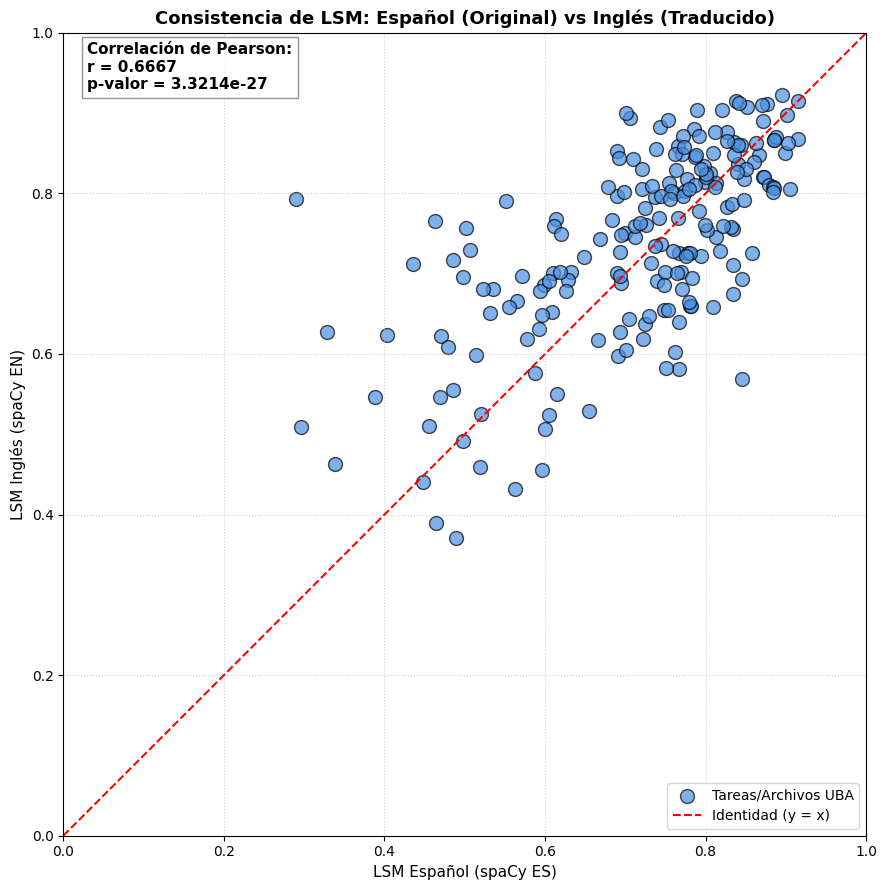

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr
from pathlib import Path

# ==========================
# Configuración de Rutas
# ==========================
RUTA_CSV_ES = "/home/tgallo/Documents/Proyecto_modular/LSM_SPACY_UBA.csv"
RUTA_CSV_EN = "/home/tgallo/Documents/Proyecto_modular/LSM_SPACY_UBA_EN.csv"

def plot_comparacion_es_vs_en(csv_es_path, csv_en_path, rango_min=0.5):
    # 1. Cargar DataFrames
    df_es = pd.read_csv(csv_es_path)
    df_en = pd.read_csv(csv_en_path)

    print(f"✎ Cargando CSV Español: {csv_es_path} ({len(df_es)} filas)")
    print(f"✎ Cargando CSV Inglés: {csv_en_path} ({len(df_en)} filas)")
    
    # 2. Normalizar la columna 'archivo' para que coincidan las claves de cruce
    # Eliminamos prefijos o sufijos como '_EN' si existieran
    df_es['id_clave'] = df_es['archivo'].str.replace('_EN', '', regex=False)
    df_en['id_clave'] = df_en['archivo'].str.replace('_EN', '', regex=False)

    # 3. Unir ambos DataFrames por la clave
    df_merged = pd.merge(
        df_es[['id_clave', 'lsm', 'batch']], 
        df_en[['id_clave', 'lsm']], 
        on='id_clave', 
        suffixes=('_es', '_en')
    )

    # 4. Eliminar filas donde alguno de los dos valores sea NaN/None
    df_clean = df_merged.dropna(subset=['lsm_es', 'lsm_en']).copy()

    if df_clean.empty:
        print("✗ No se encontraron coincidencias válidas entre ambos CSV.")
        return

    # 5. Cálculo de Correlación de Pearson
    r_value, p_value = pearsonr(df_clean['lsm_es'], df_clean['lsm_en'])

    # 6. Graficar
    plt.figure(figsize=(9, 9))
    
    # Puntos de dispersión (color violeta/azulado)
    plt.scatter(
        df_clean['lsm_es'], 
        df_clean['lsm_en'], 
        color='#4a90e2', 
        s=100, 
        alpha=0.7, 
        edgecolors='black', 
        label='Tareas/Archivos UBA'
    )

    # Línea de identidad (y = x)
    identidad = np.linspace(rango_min, 1, 100)
    plt.plot(identidad, identidad, color='red', linestyle='--', label='Identidad (y = x)')

    # Texto con los resultados estadísticos
    texto_stats = f'Correlación de Pearson:\nr = {r_value:.4f}\np-valor = {p_value:.4e}'
    plt.text(
        rango_min + 0.03, 0.93, 
        texto_stats, 
        fontsize=11, 
        fontweight='bold', 
        bbox=dict(facecolor='white', alpha=0.85, edgecolor='gray')
    )

    # Configuración de ejes y visualización
    plt.xlim(rango_min, 1.0)
    plt.ylim(rango_min, 1.0)
    plt.title('Consistencia de LSM: Español (Original) vs Inglés (Traducido)', fontsize=13, fontweight='bold')
    plt.xlabel('LSM Español (spaCy ES)', fontsize=11)
    plt.ylabel('LSM Inglés (spaCy EN)', fontsize=11)
    plt.gca().set_aspect('equal')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

# Ejecutar gráfico
if __name__ == "__main__":
    plot_comparacion_es_vs_en(RUTA_CSV_ES, RUTA_CSV_EN, rango_min=0)

ENTR VS


Switchboard: 461 pares emparejados


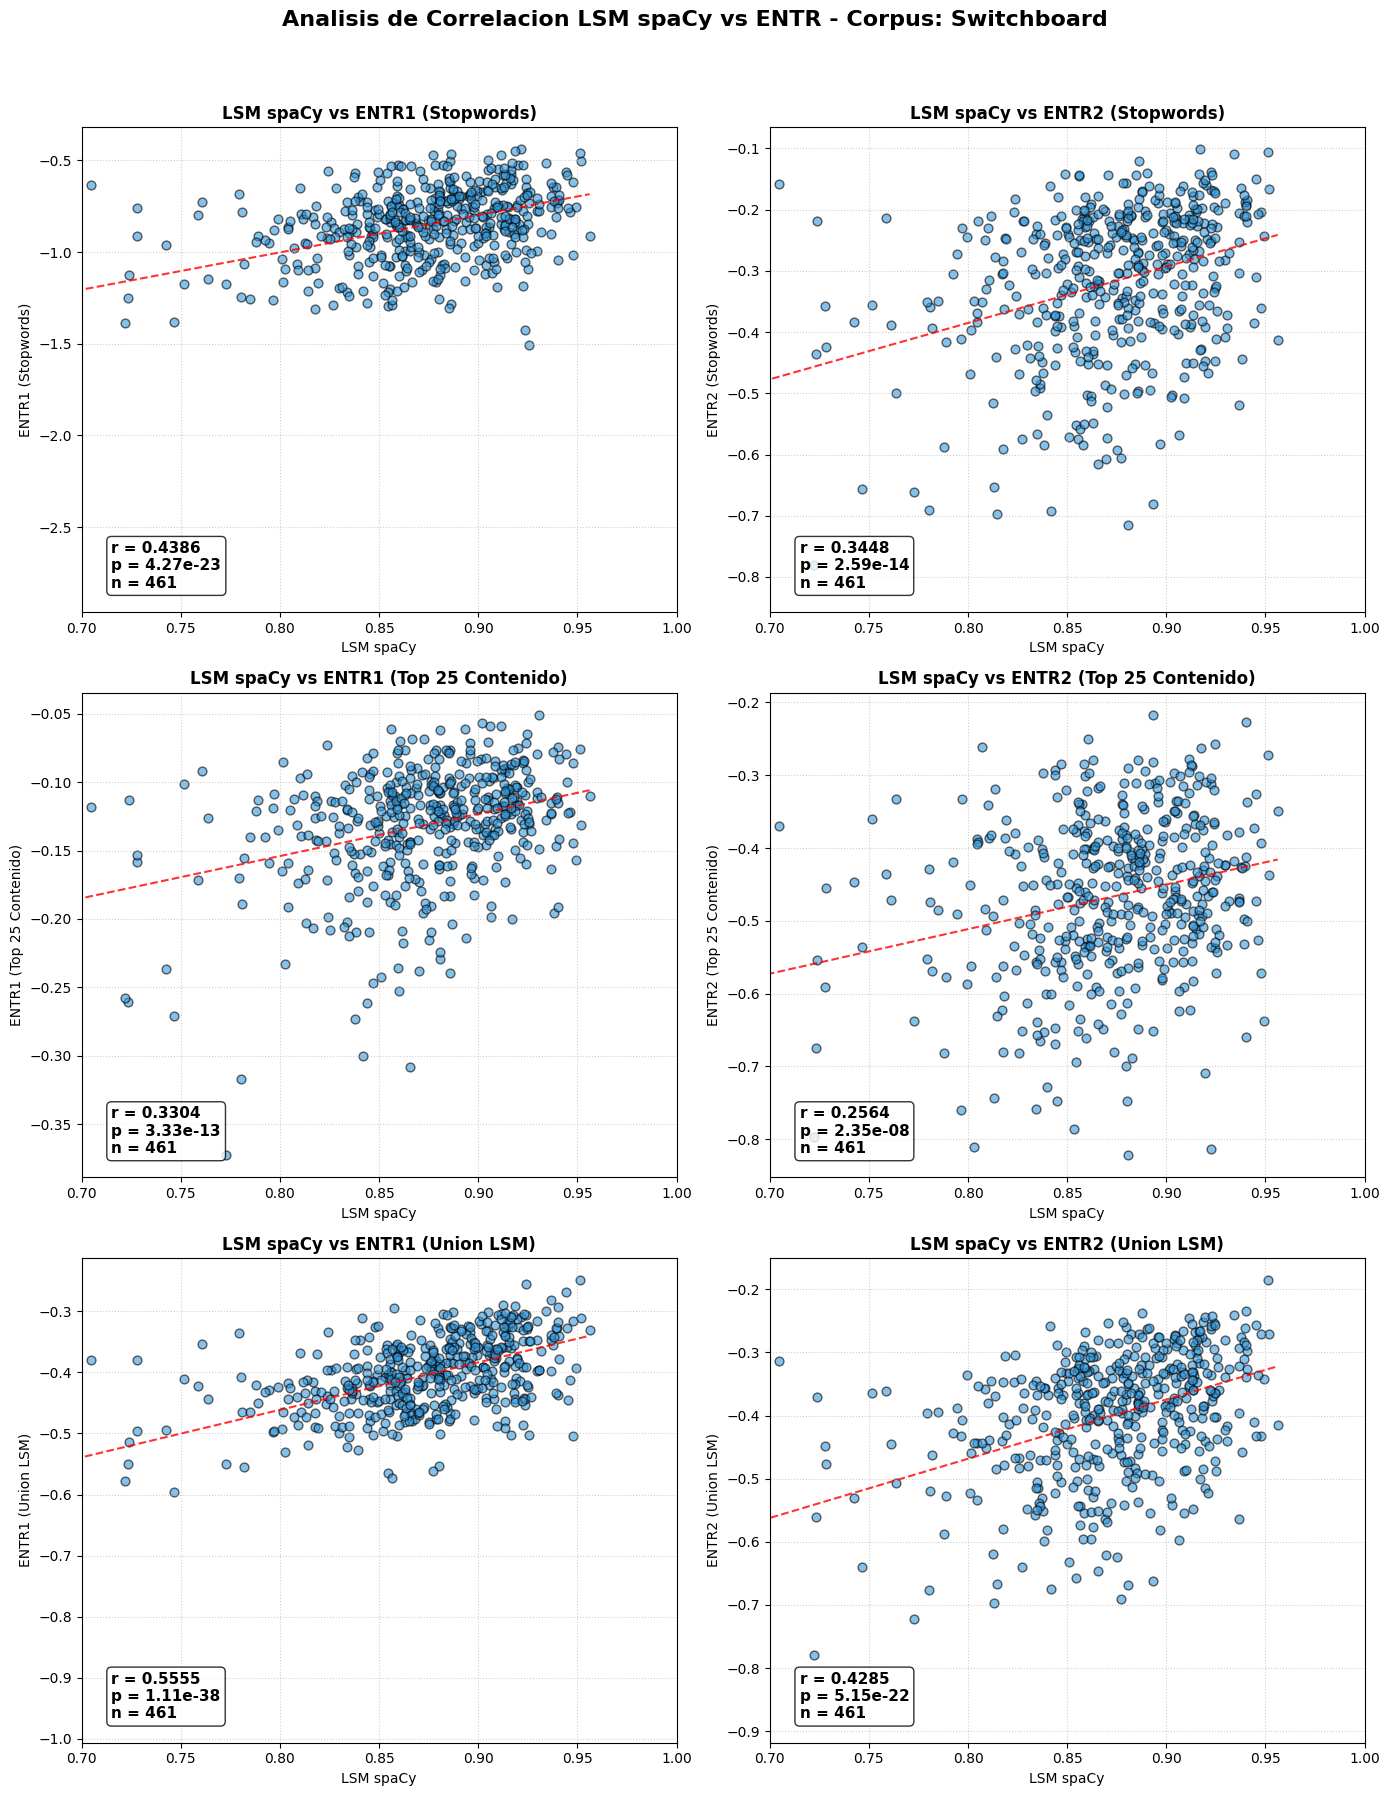

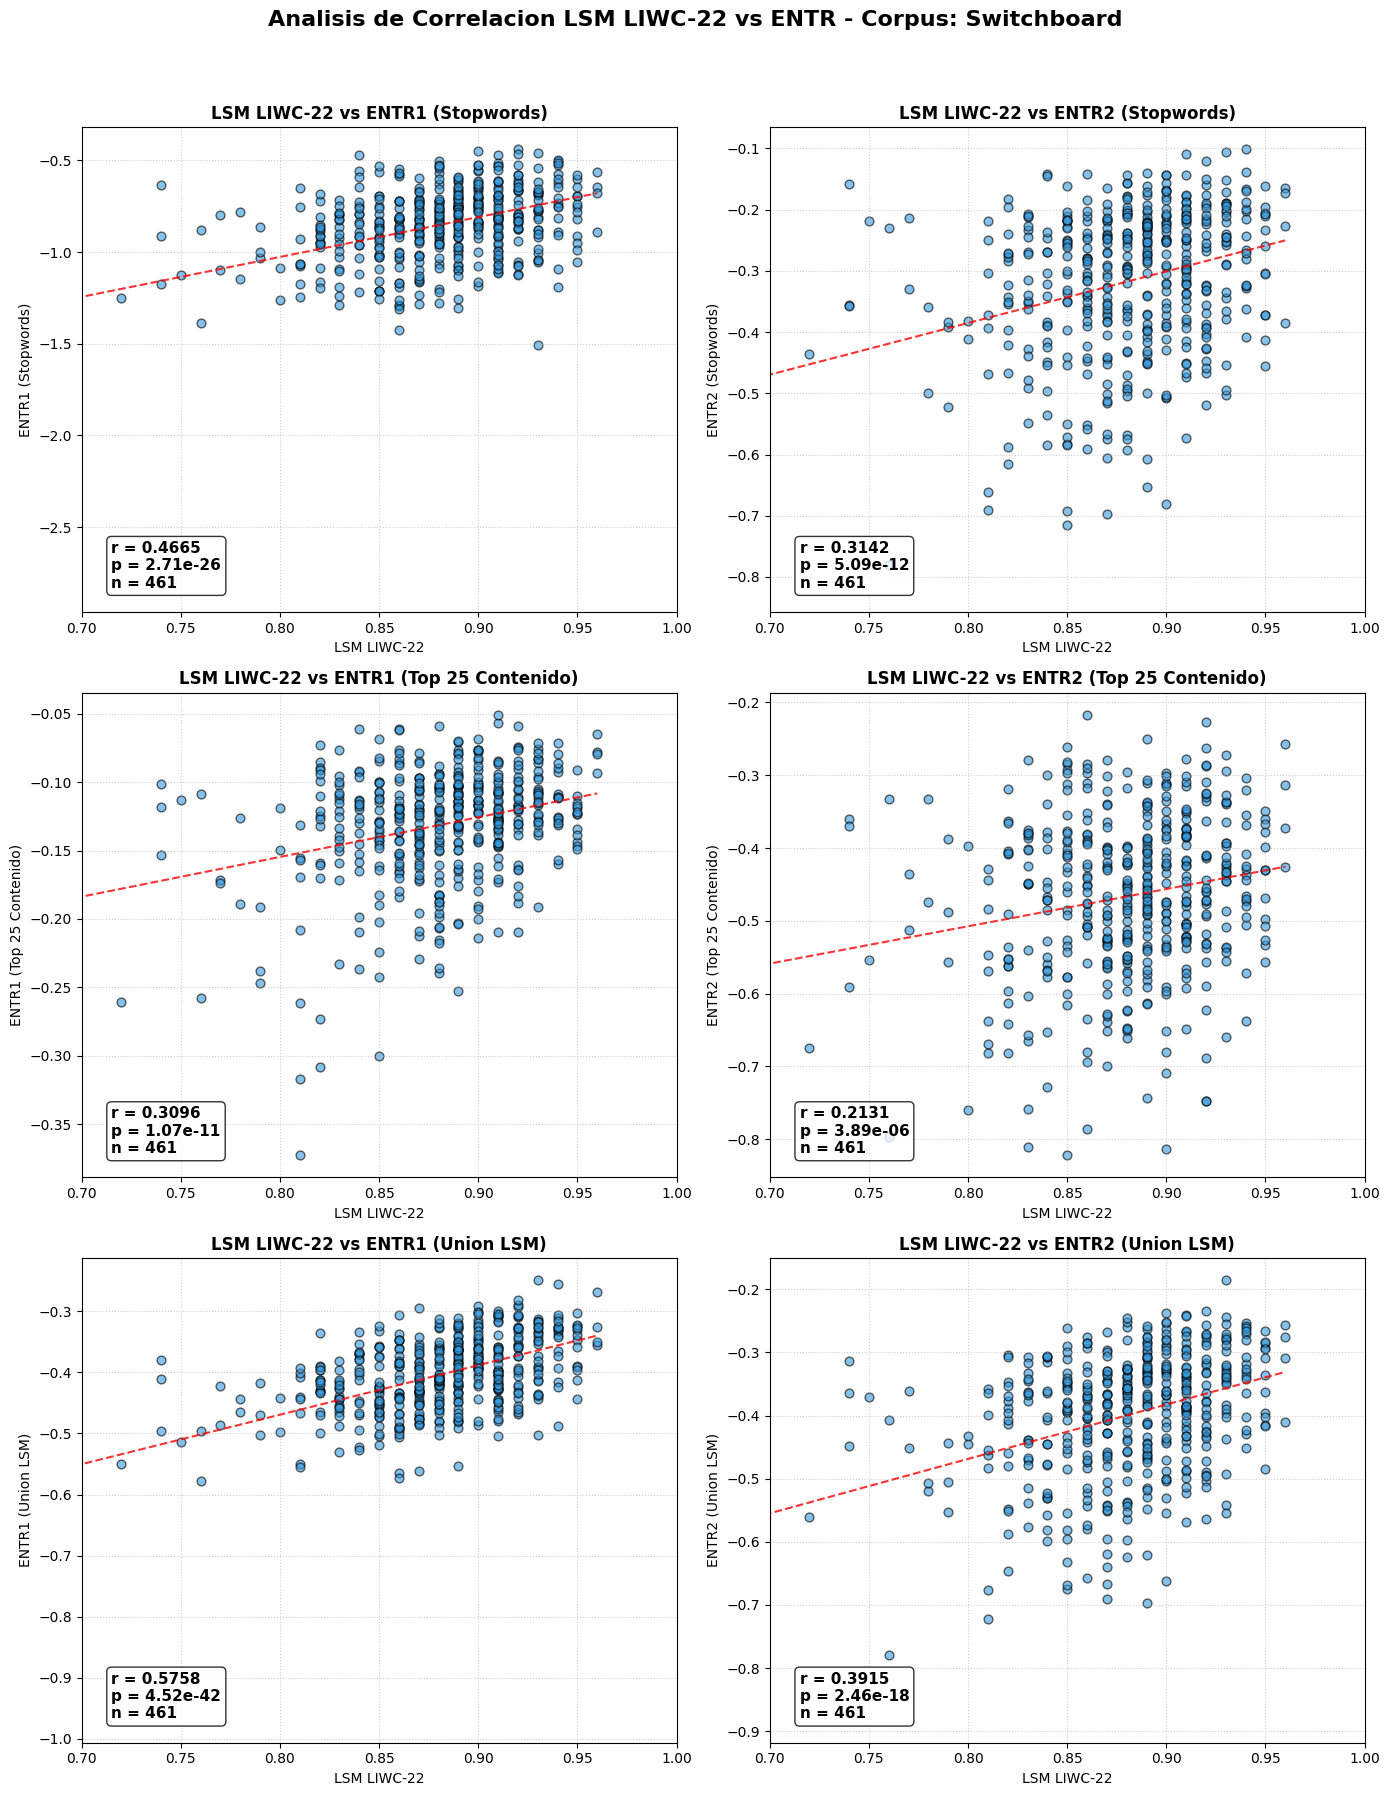


SCOTUS: 228 pares emparejados


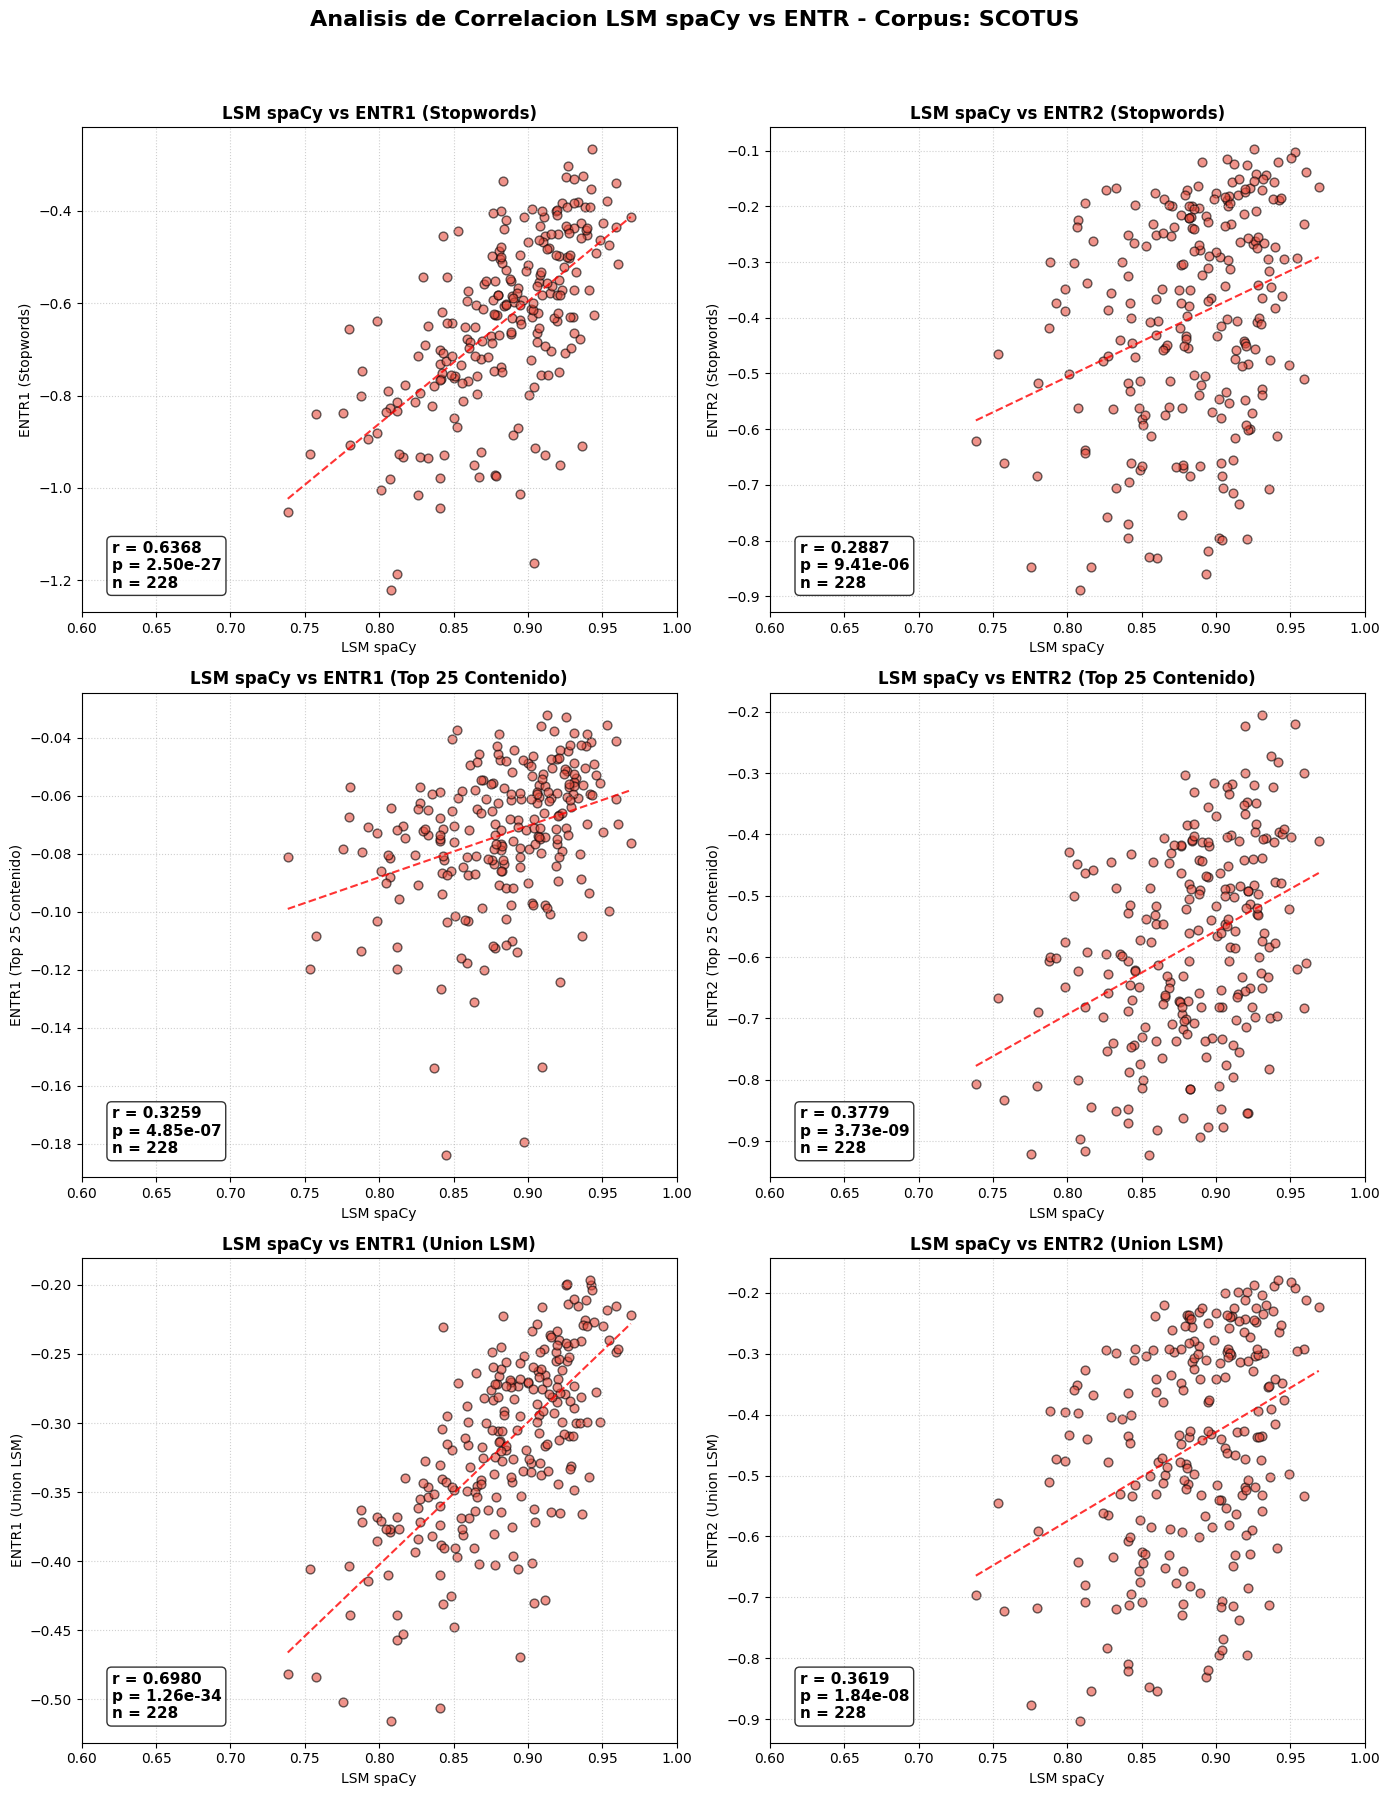

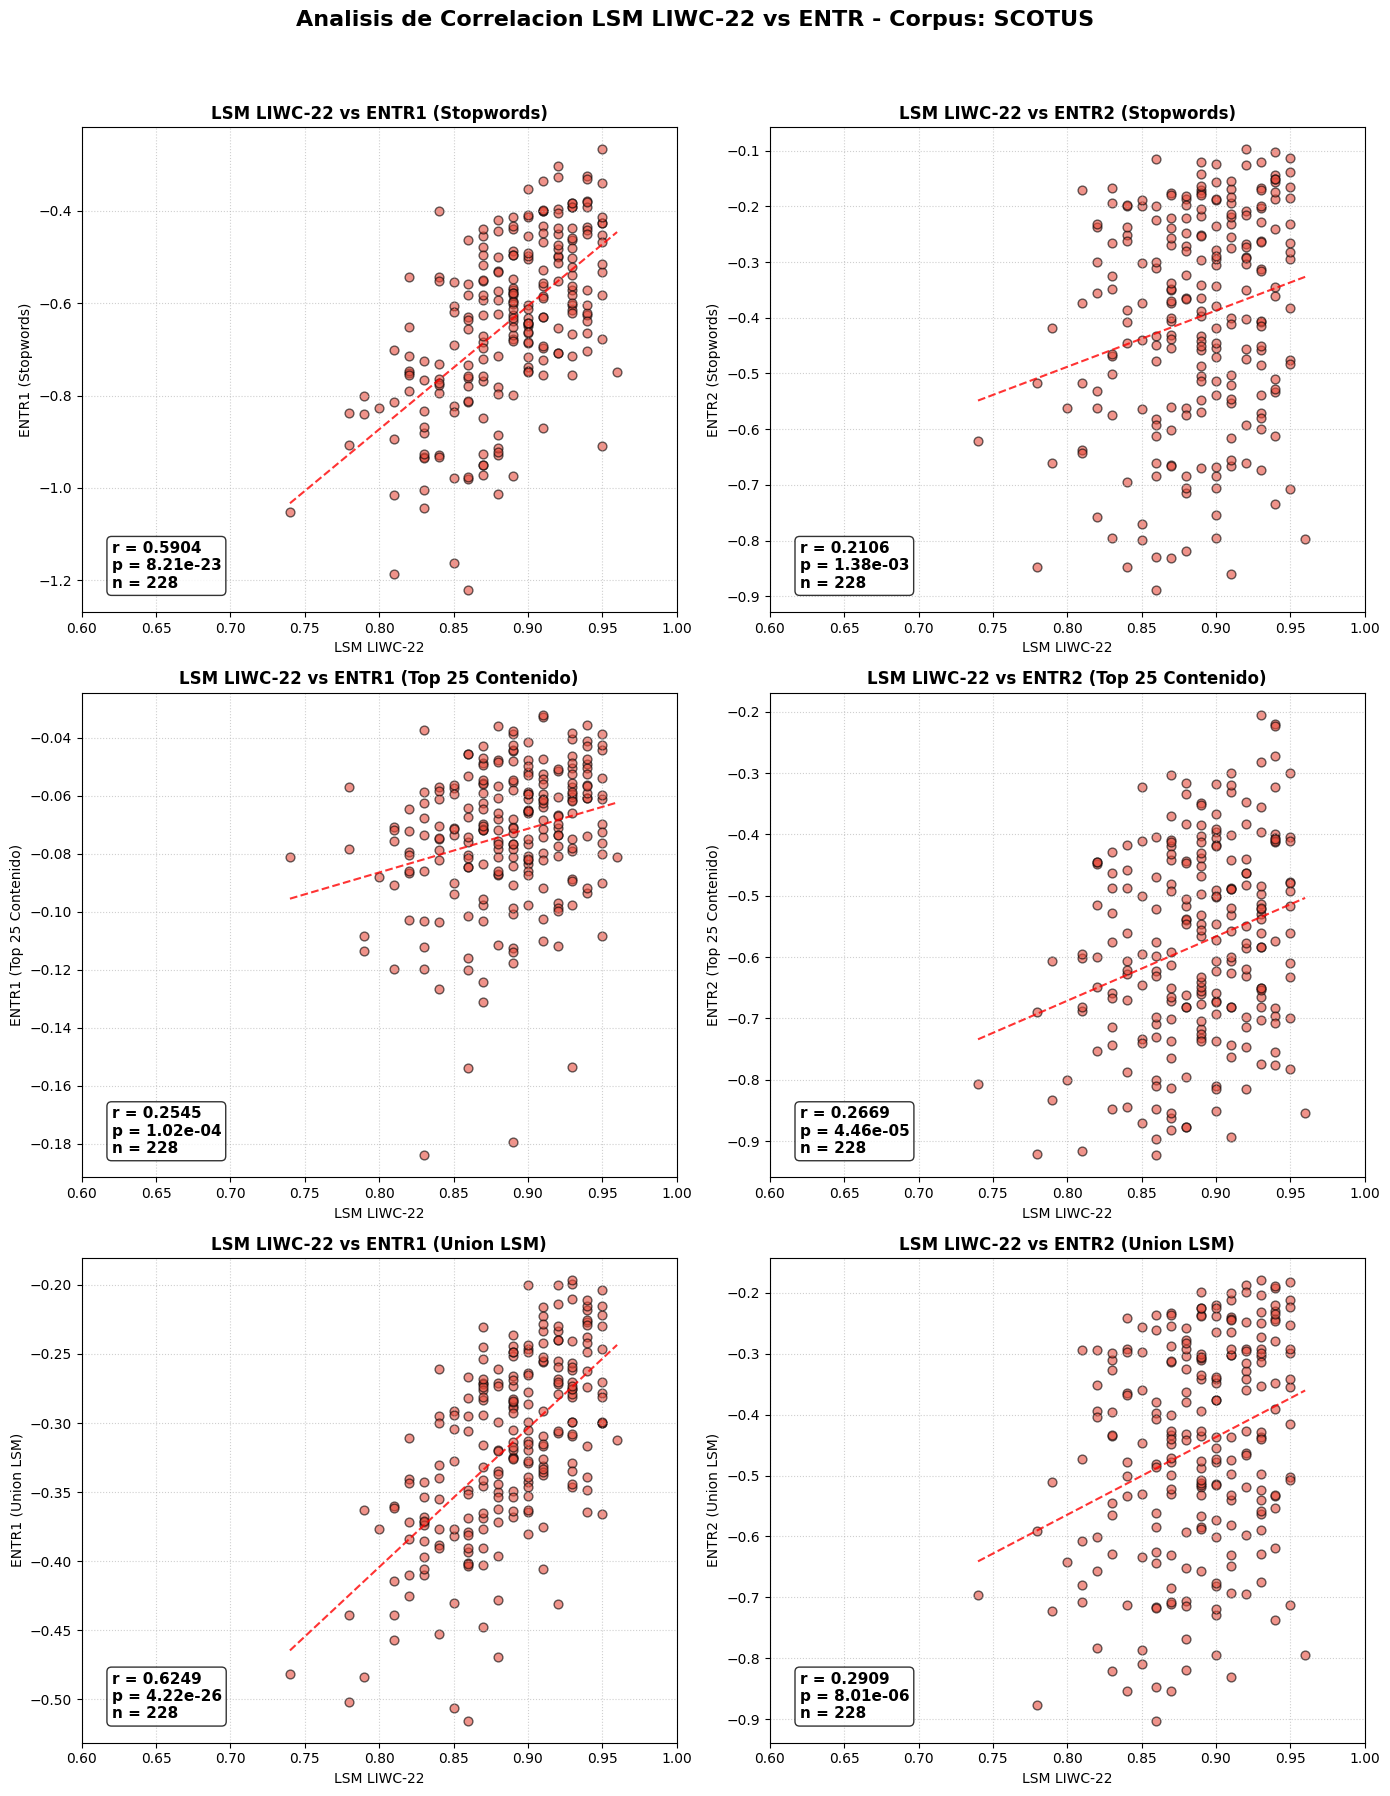


CGC: 115 pares emparejados


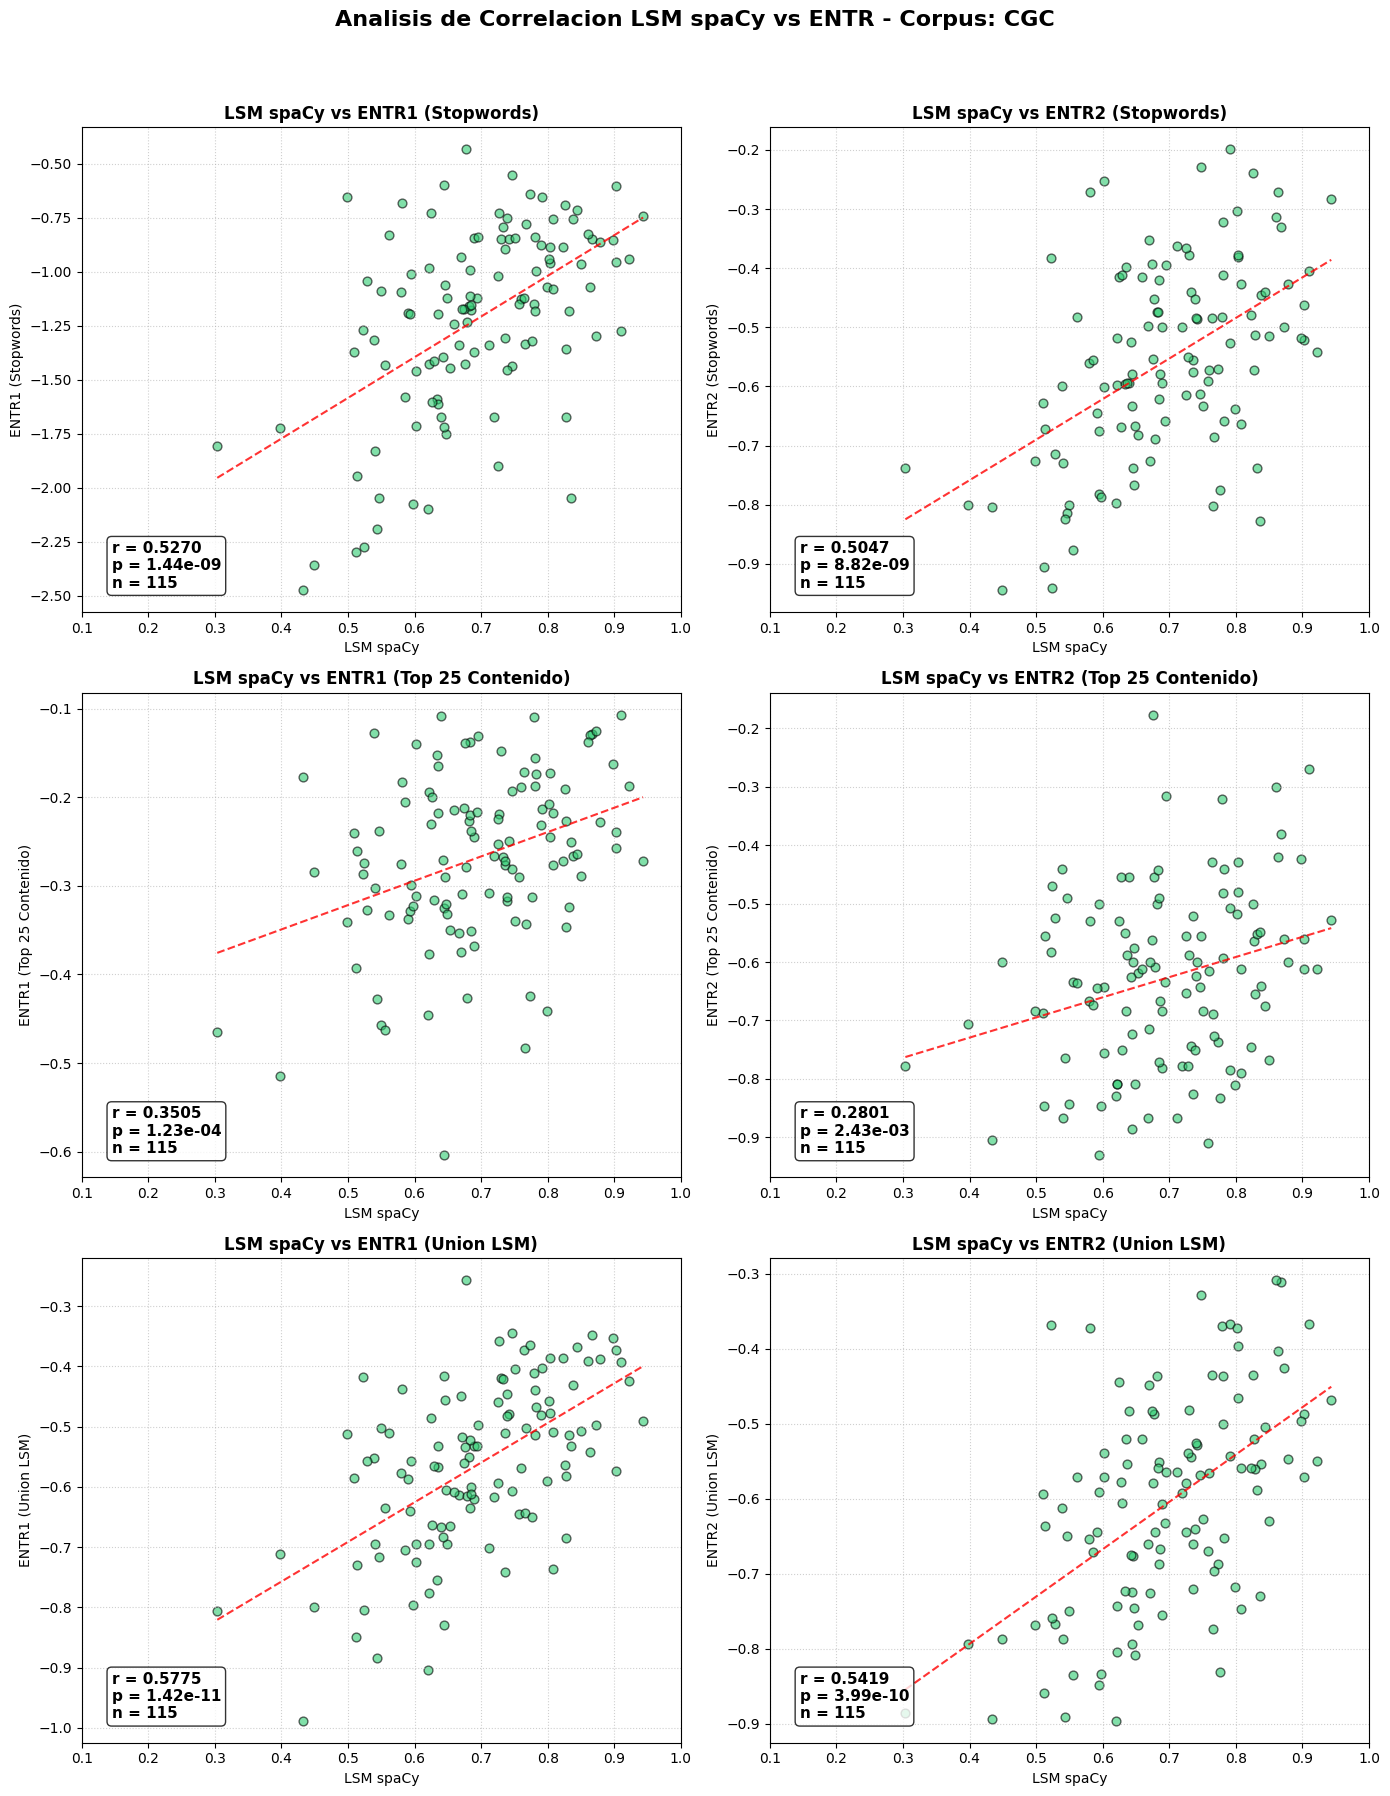

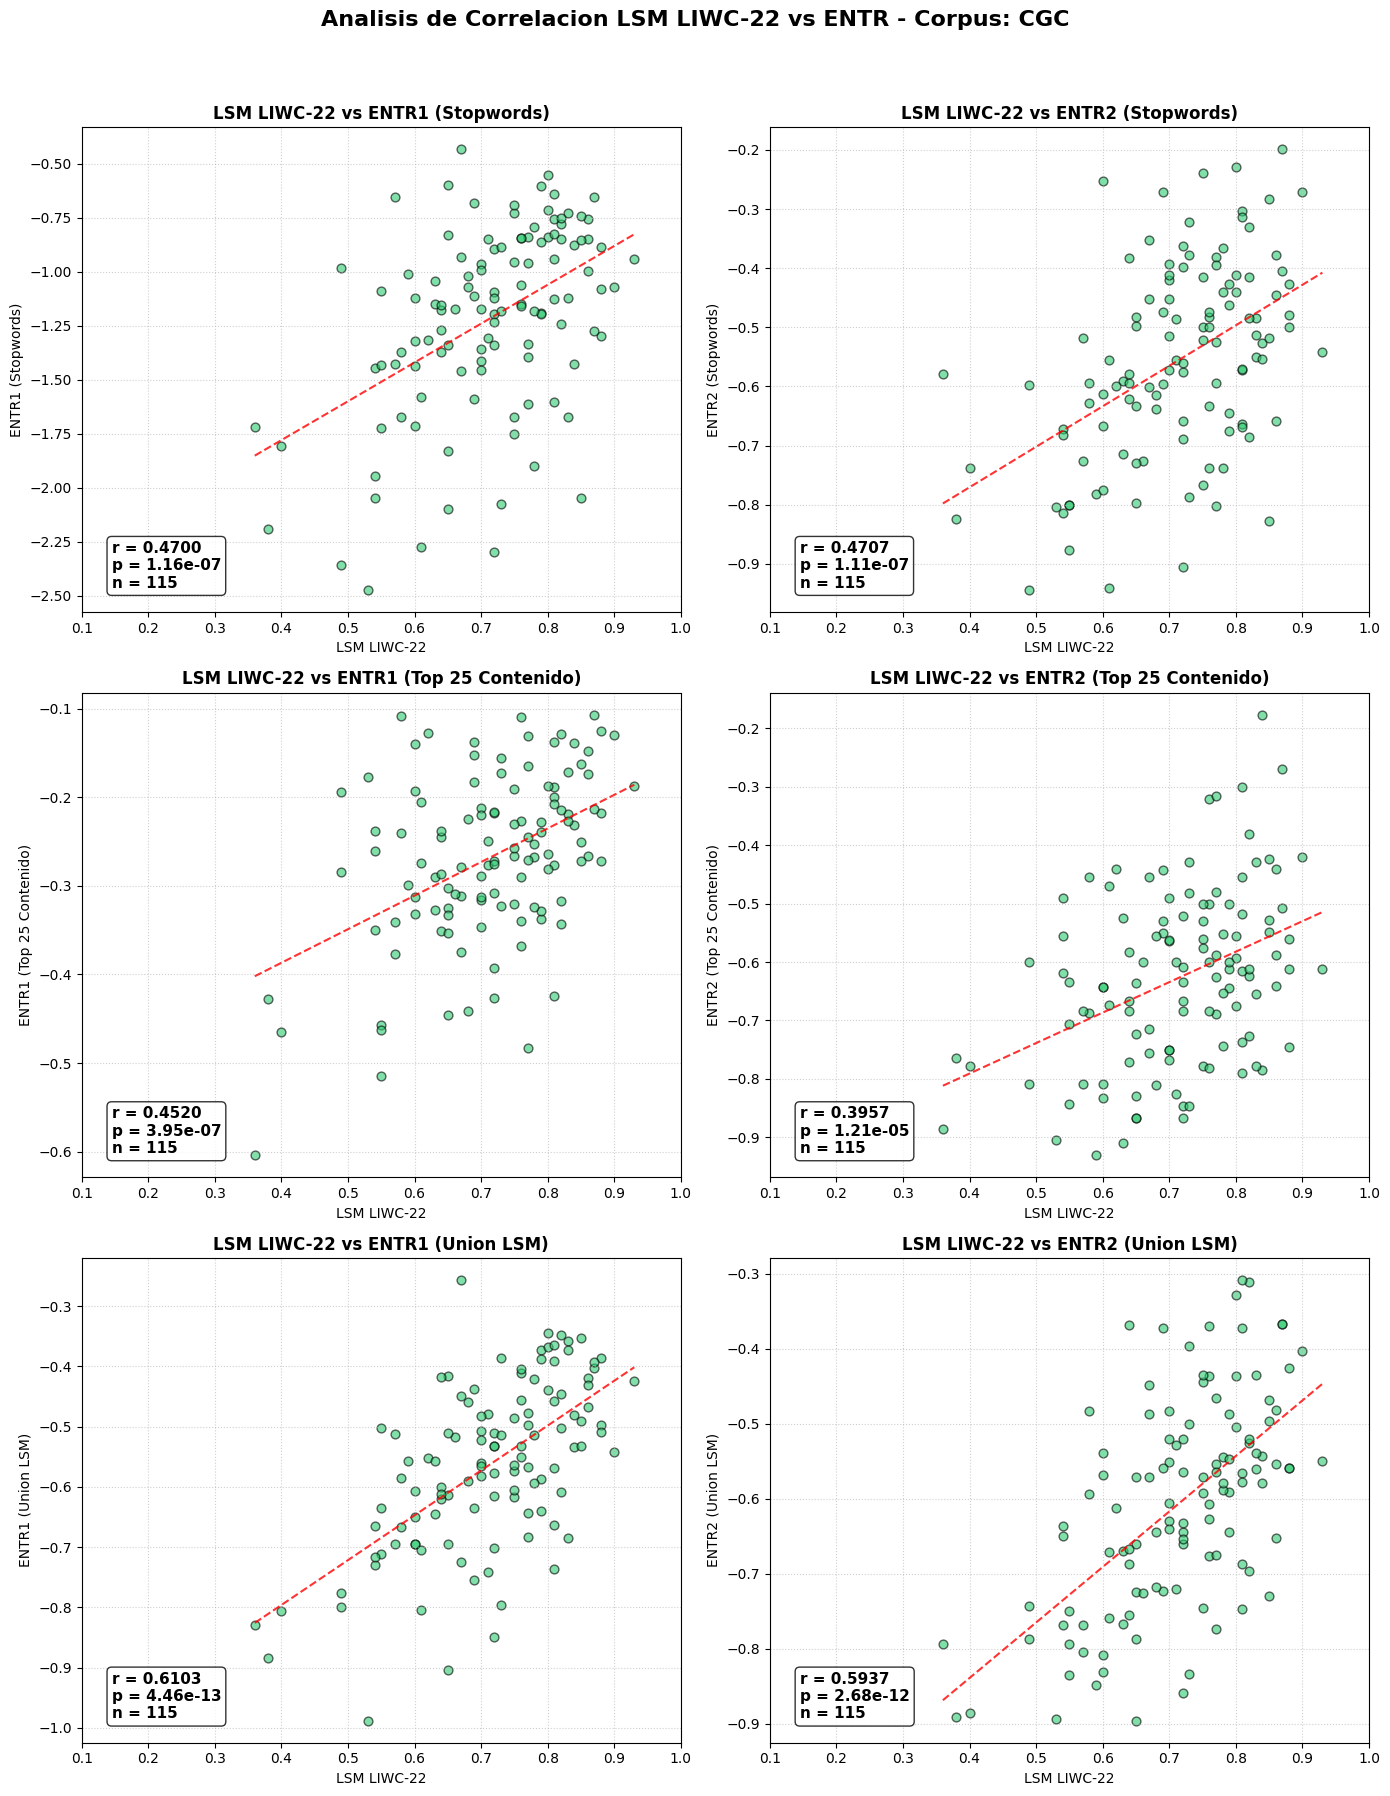


Total de grillas mostradas: 6 (cada una con 6 subgraficos = 36 graficos individuales)


In [7]:
"""
Genera TODOS los gráficos de la matriz:
  {LSM_Spacy, LSM_LIWC} x {ENTR1, ENTR2} x {Stopwords, Top25, Union LSM} x {Switchboard, SCOTUS, CGC}

Por cada corpus y cada fuente de LSM se arma una grilla 3x2 (filas = clase,
columnas = ENTR1/ENTR2)
pero repetido para lsm_model (spaCy) y para lsm_liwc.

Los límites del eje X (LSM) se configuran por corpus en LIMITES_X, y se
aplican a los 6 subgráficos de cada grilla (para lsm_model y lsm_liwc).
"""

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import pearsonr

CARPETA = "/home/tgallo/Documents/Proyecto_modular"

# ---- Definición de corpus disponibles (LSM + ENTR) ----
CORPUS = [
    # nombre, archivo_lsm, archivo_entr, columna_id_para_mergear, color
    ("Switchboard", "LSM_SPACY_SW.csv",     "ENTR_SPACY_SW.csv",     "archivo",    "#3498db"),
    ("SCOTUS",      "LSM_SPACY_SCOTUS.csv", "ENTR_SPACY_SCOTUS.csv", "id_virtual", "#e74c3c"),
    ("CGC", "LSM_SPACY_CGC.csv", "ENTR_SPACY_CGC.csv", "archivo", "#2ecc71"),
]


# ---- Las 2 fuentes de LSM a comparar contra la entropia ----
FUENTES_LSM = [
    ("lsm_model", "LSM spaCy"),
    ("lsm_liwc",  "LSM LIWC-22"),
]

# ---- Límites del eje X (LSM) por corpus. Se aplican a los 6 subgráficos ----
# de la grilla, tanto para lsm_model como para lsm_liwc.
# Poné None si querés que el límite se ajuste solo.
LIMITES_X = {
    "Switchboard": (0.7, 1.0),
    "SCOTUS":      (0.6, 1.0),
    "CGC":         (0.1, 1.0),
}

# ---- Las 6 combinaciones metrica x clase ----
COMBINACIONES_ENTR = [
    ("entr1_clase1", "ENTR1 (Stopwords)"),
    ("entr2_clase1", "ENTR2 (Stopwords)"),
    ("entr1_clase2", "ENTR1 (Top 25 Contenido)"),
    ("entr2_clase2", "ENTR2 (Top 25 Contenido)"),
    ("entr1_clase3", "ENTR1 (Union LSM)"),
    ("entr2_clase3", "ENTR2 (Union LSM)"),
]


def graficar_grilla(df, corpus_nombre, col_lsm, nombre_lsm, color_puntos):
    """Grilla 3x2: cada clase (stopwords/top25/union) x cada metrica (entr1/entr2),
    todas contra la misma columna de LSM (spaCy o LIWC)."""

    fig, axes = plt.subplots(3, 2, figsize=(14, 18))
    axes = axes.flatten()

    x_data = df[col_lsm]

    for i, (col_entr, nombre_entr) in enumerate(COMBINACIONES_ENTR):
        ax = axes[i]
        y_data = df[col_entr]

        r_value, p_value = pearsonr(x_data, y_data)

        ax.scatter(x_data, y_data, color=color_puntos, s=40, alpha=0.6, edgecolors="black")

        m, b = np.polyfit(x_data, y_data, 1)
        xs = np.linspace(x_data.min(), x_data.max(), 100)
        ax.plot(xs, m * xs + b, color="red", linestyle="--", alpha=0.8, label="Tendencia")

        ax.set_title(f"{nombre_lsm} vs {nombre_entr}", fontsize=12, fontweight="bold")
        ax.set_xlabel(nombre_lsm, fontsize=10)
        ax.set_ylabel(nombre_entr, fontsize=10)
        ax.grid(True, linestyle=":", alpha=0.6)

        xlim = LIMITES_X.get(corpus_nombre)
        if xlim is not None:
            ax.set_xlim(*xlim)

        ax.text(
            0.05, 0.05, f"r = {r_value:.4f}\np = {p_value:.2e}\nn = {len(df)}",
            transform=ax.transAxes, fontsize=11, fontweight="bold",
            bbox=dict(facecolor="white", alpha=0.8, boxstyle="round,pad=0.3"),
        )

    plt.suptitle(
        f"Analisis de Correlacion {nombre_lsm} vs ENTR - Corpus: {corpus_nombre}",
        fontsize=16, fontweight="bold", y=0.995,
    )
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


def main():
    total_grillas = 0
    for corpus_nombre, f_lsm, f_entr, on_col, color in CORPUS:
        ruta_lsm = os.path.join(CARPETA, f_lsm)
        ruta_entr = os.path.join(CARPETA, f_entr)

        if not os.path.exists(ruta_lsm) or not os.path.exists(ruta_entr):
            print(f"Saltando {corpus_nombre}: falta {f_lsm} o {f_entr}")
            continue

        df_lsm = pd.read_csv(ruta_lsm)
        df_entr = pd.read_csv(ruta_entr)
        df = pd.merge(df_lsm, df_entr, on=on_col, how="inner").dropna()

        if df.empty:
            print(f"Merge vacio para {corpus_nombre}")
            continue

        print(f"\n{corpus_nombre}: {len(df)} pares emparejados")

        for col_lsm, nombre_lsm in FUENTES_LSM:
            graficar_grilla(df, corpus_nombre, col_lsm, nombre_lsm, color)
            total_grillas += 1

    print(f"\nTotal de grillas mostradas: {total_grillas} (cada una con 6 subgraficos = {total_grillas*6} graficos individuales)")


main()